# EDA — DataCo Smart Supply Chain

## Objective
The purpose of this exploratory analysis is to **deeply understand** the dataset and to **justify** every decision that will be implemented in the data cleaning pipeline (Sprint 2).  
The final decisions are centralized in the last section.

## Detailed Notebook Plan
1. **Snapshot** – size, memory usage, data dictionary  
2. **Grain & Candidate Keys** – identification of the primary key and foreign keys  
3. **Types & Missing Values** – comparison between pandas / PySpark, columns to convert, null rate  
4. **Duplicates** – checking for exact and logical duplicates  
5. **Descriptive Statistics & Outliers** – analysis of numerical and categorical columns, outlier detection  
6. **Cardinalities & Relationships (ERD)** – cardinalities, primary/foreign keys  
7. **Entity Discovery** – mapping to the 3NF model (tables: Customer, Product, Order, Order_Details, Shipment, Category, Department)  
8. **Additional Checks** – distribution & skew, temporal integrity, referential integrity, sampling, volatility, business sanity checks  
9. **Final Cleaning Decisions Table** – all actions (drops, conversions, null handling) with justifications

- **Pandas**: main tool for descriptive statistics (fast and readable).  
- **PySpark**: used for cardinality aggregations (convenient for the rest of the project).

In [1]:
import pandas as pd
import numpy as np
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, countDistinct

# Spark session
spark = SparkSession.builder.appName("EDA").getOrCreate()

# Loading data
df = pd.read_csv('../data/raw/DataCoSupplyChainDataset.csv', encoding='latin1')
df_desc = pd.read_csv('../data/raw/DescriptionDataCoSupplyChain.csv')
df_spark = spark.read.csv('../data/raw/DataCoSupplyChainDataset.csv', header=True, inferSchema=True)



In [2]:
# Display the first 10 rows of the PySpark DataFrame
df_spark.show(10, truncate=False)

+--------+------------------------+-----------------------------+-----------------+------------------+-----------------+------------------+-----------+--------------+-------------+----------------+--------------+--------------+-----------+--------------+-----------------+----------------+--------------+------------------------+----------------+-------------+---------------+-----------+------------+------------+----------+-------------+-----------------+-----------------------+--------+----------------------+-------------------+------------------------+-------------+------------------------+-----------------------+-------------------+------+----------------+----------------------+--------------+---------------+---------------+-------------+---------------+-------------------+-------------------+--------------------------------------------+------------+-------------+--------------+--------------------------+--------------+
|Type    |Days for shipping (real)|Days for shipment (scheduled)|

## 1) Snapshot dataset

In [3]:
print("Shape:", df.shape) #number of rows and columns
print("Memory usage:", df.memory_usage(deep=True).sum() / 1e6, "MB") #memory usage in MB (total bytes used by all columns)

df.info() #index range, column names, non-null counts, data types and memory


Shape: (180519, 53)
Memory usage: 134.511859 MB
<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Email                 180519 non-null  str   

In [4]:
# Data dictionary 
print("Description file shape:", df_desc.shape)
display(df_desc.head())

# Undocumented / Extra Columns in the Dataset (if needed)
desc_fields = set(df_desc['FIELDS'].astype(str))
missing_in_desc = [c for c in df.columns if c not in desc_fields]
print("Columns missing in description:", missing_in_desc)


Description file shape: (52, 2)


,FIELDS,DESCRIPTION
0,Type,: Type of transaction made
1,Days for shipping (real),: Actual shipping days of the purchased product
2,Days for shipment (scheduled),: Days of scheduled delivery of the purchased...
3,Benefit per order,: Earnings per order placed
4,Sales per customer,: Total sales per customer made per customer


Columns missing in description: ['Days for shipping (real)', 'Late_delivery_risk', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Total', 'Order Zipcode', 'shipping date (DateOrders)']


### Summary
- **Shape**: 180,519 rows × 53 columns 
- **Memory footprint (Pandas)**: 348.8 MB (deep). `df.info()` only shows 73 MB because it ignores the overhead of object columns.

## 2) Grain & Candidate Keys

In [5]:
# Filter "id" columns 
id_columns_desc = df_desc[df_desc['FIELDS'].str.contains('id', case=False, na=False)]
id_columns_desc[['FIELDS', 'DESCRIPTION']]

,FIELDS,DESCRIPTION
7,Category Id,: Product category code
13,Customer Id,: Customer ID
20,Department Id,: Department code of store
27,Order Customer Id,: Customer order code
29,Order Id,: Order code
30,Order Item Cardprod Id,: Product code generated through the RFID reader
33,Order Item Id,: Order item code
43,Product Card Id,: Product code
44,Product Category Id,: Product category code


### Identifier Columns Not Candidates for Grain Analysis

The following columns are not candidates because they naturally repeat in the dataset:

| Column                  | Reason for Not Being a Candidate |
|-------------------------|----------------------------------|
| `Customer Id`           | Customer identifier. A customer can place multiple orders. |
| `Order Customer Id`     | Redundant with `Customer Id` (according to the description). It also repeats. |
| `Product Card Id`       | Product identifier. A product can be sold multiple times. |
| `Product Category Id`   | Category identifier. A category contains multiple products. |
| `Category Id`           | Redundant with `Product Category Id`. |
| `Department Id`         | Department identifier. A department contains multiple categories. |
| `Order Item Cardprod Id`| Another product identifier (RFID). Redundant with `Product Card Id`. |

In [6]:
from pyspark.sql.functions import countDistinct

total_rows = df_spark.count()
distinct_orders = df_spark.select("Order Id").distinct().count()
distinct_items = df_spark.select("Order Item Id").distinct().count()

print("Total rows:", total_rows)
print("Distinct Order Id:", distinct_orders)
print("Distinct Order Item Id:", distinct_items)

Total rows: 180519
Distinct Order Id: 65752
Distinct Order Item Id: 180519


### Conclusion

- **Total rows**: 180,519  
- **`Order Item Id` distinct values**: 180,519 → exactly the same number as the total rows.  
  → `Order Item Id` is **unique**: it is a candidate primary key.

- **`Order Id` distinct values**: 65,752 → lower than the total number of rows.  
  → Each `Order Id` appears multiple times.  
  → Therefore, one order contains multiple lines.

**Conclusion**:  
The grain of the file is **one row per ordered product** (order line item).  
The natural primary key is `Order Item Id`.  
`Order Id` will serve as a foreign key to an `Order` table in the relational model.

## 3) Types, Missing Values & Conversions (Decisions)

In [7]:
# 1) Pandas Types + PySpark Types + Compare Mismatches
import numpy as np

pandas_types = df.dtypes.astype(str).to_dict()
spark_types = dict(df_spark.dtypes)

def simp_pandas(t: str) -> str:
    t = t.lower()
    if 'int' in t:
        return 'integer'
    if 'float' in t:
        return 'double'
    if 'object' in t or 'string' in t or 'str' in t:
        return 'string'
    return t

def simp_spark(t: str) -> str:
    t = (t or '').lower()
    if t in {'int', 'integer', 'bigint', 'smallint', 'tinyint'}:
        return 'integer'
    if t in {'double', 'float', 'decimal'}:
        return 'double'
    if t in {'string'}:
        return 'string'
    return t

rows = []
for c in df.columns:
    pt = simp_pandas(pandas_types.get(c, 'unknown'))
    st = simp_spark(spark_types.get(c, 'unknown'))
    if pt != st:
        rows.append((c, pandas_types.get(c), spark_types.get(c), pt, st))

mismatch_df = pd.DataFrame(rows, columns=['column','pandas_type','spark_type','pandas_simplified','spark_simplified'])
if len(mismatch_df) == 0:
    print('No pandas vs PySpark type mismatches.')
else:
    display(mismatch_df)

,column,pandas_type,spark_type,pandas_simplified,spark_simplified
0,Customer Zipcode,float64,int,double,integer
1,Order Zipcode,float64,int,double,integer
2,Product Description,float64,string,double,string


In [8]:
# 2) Identify columns containing nulls + null rate for each
null_counts = df.isnull().sum()
null_rates = (null_counts / len(df)) * 100
null_info = pd.DataFrame({'null_count': null_counts, 'null_percent': null_rates})
null_info = null_info[null_info['null_count'] > 0].sort_values('null_count', ascending=False)
print("\nColumns with missing values:")
display(null_info)


Columns with missing values:


,null_count,null_percent
Product Description,180519,100.000000
Order Zipcode,155679,86.239676
Customer Lname,8,0.004432
Customer Zipcode,3,0.001662


In [11]:
# 3) Date columns + check of their current types
date_cols = [c for c in df.columns if 'date' in c.lower()]
print("\nColumns containing 'date':", date_cols)
print("Current types (pandas):")
print(df[date_cols].dtypes)
print("\nSample values (first rows):")
print(df[date_cols].head())


Columns containing 'date': ['order date (DateOrders)', 'shipping date (DateOrders)']
Current types (pandas):
order date (DateOrders)       str
shipping date (DateOrders)    str
dtype: object

Sample values (first rows):
  order date (DateOrders) shipping date (DateOrders)
0         1/31/2018 22:56             2/3/2018 22:56
1         1/13/2018 12:27            1/18/2018 12:27
2         1/13/2018 12:06            1/17/2018 12:06
3         1/13/2018 11:45            1/16/2018 11:45
4         1/13/2018 11:24            1/15/2018 11:24


### Summary
The **columns to convert or drop** and their justifications are listed in the table below.

In [13]:
reco = []

# Handling of date columns
for c in date_cols:
    reco.append((c, 'PARSE_TO_DATE/TIMESTAMP', 'date column detected (currently string)'))

# Handling of other columns with nulls (exclude dates already processed)
for c, row in null_info.iterrows():
    if c in date_cols:
        continue
    pct = row['null_percent']
    if pct > 80.0:
        reco.append((c, 'DROP_COLUMN', f'{pct:.1f}% nulls'))
    elif 0 < pct < 5.0:
        reco.append((c, 'DROP_ROWS', f'{pct:.3f}% nulls (drop the few affected rows)'))

reco_df = pd.DataFrame(reco, columns=['column','action','why']).drop_duplicates('column')
print("\nCleaning recommendations:")
display(reco_df)


Cleaning recommendations:


,column,action,why
0,order date (DateOrders),PARSE_TO_DATE/TIMESTAMP,date column detected (currently string)
1,shipping date (DateOrders),PARSE_TO_DATE/TIMESTAMP,date column detected (currently string)
2,Product Description,DROP_COLUMN,100.0% nulls
3,Order Zipcode,DROP_COLUMN,86.2% nulls
4,Customer Lname,DROP_ROWS,0.004% nulls (drop the few affected rows)
5,Customer Zipcode,DROP_ROWS,0.002% nulls (drop the few affected rows)


## 4) Duplicates

In [14]:
# 1. Exact duplicates (identical rows across all columns)
exact_duplicates = df.duplicated().sum()
print(f"Number of exactly duplicated rows: {exact_duplicates}")

# 2. Check if the candidate primary key (Order Item Id) is unique
pk_duplicates = df['Order Item Id'].duplicated().sum()
print(f"Number of duplicates on Order Item Id: {pk_duplicates}")

# 3. Check for logical duplicates on (Order Id, Order Item Id)
logical_duplicates = df.duplicated(subset=['Order Id', 'Order Item Id']).sum()
print(f"Duplicates on (Order Id, Order Item Id): {logical_duplicates}")

# (Optional) Display an example if duplicates exist
if logical_duplicates > 0:
    print("\nExamples of logical duplicates:")
    print(df[df.duplicated(subset=['Order Id', 'Order Item Id'], keep=False)].head(5))

Number of exactly duplicated rows: 0
Number of duplicates on Order Item Id: 0
Duplicates on (Order Id, Order Item Id): 0


### Conclusion

- **Exactly identical rows**: 0 → no unnecessary duplication.
- **`Order Item Id` duplicates**: 0 → the candidate primary key is indeed unique.

**Conclusion**: No duplicates detected. The dataset is clean from this perspective.

## 5) Descriptive Statistics & Outliers

In [15]:
# 1. Columns to exclude from statistics

exclude_from_stats = [
    'Order Zipcode', 'Product Description', 'Product Status',   # to be dropped                 
    # Identifiers and columns irrelevant for statistics
    'Category Id', 'Customer Zipcode', 'Customer Id', 'Department Id', 'Order Customer Id',
    'Order Id', 'Order Item Cardprod Id', 'Order Item Id', 'Product Card Id',
    'Product Category Id', 'Latitude', 'Longitude'
]

# 2. Select numeric columns (int64, float64)
all_numeric = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 3. Keep only those not in the exclusion list
numeric_for_stats = [col for col in all_numeric if col not in exclude_from_stats]
print("Numeric columns for statistics:", numeric_for_stats)

# 4. Display the statistics
df[numeric_for_stats].describe()

Numeric columns for statistics: ['Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Late_delivery_risk', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Product Price']


,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Product Price
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000
mean,3.497654,2.931847,21.974989,183.107609,0.548291,20.664741,0.101668,141.232550,0.120647,2.127638,203.772096,183.107609,21.974989,141.232550
std,1.623722,1.374449,104.433526,120.043670,0.497664,21.800901,0.070415,139.732492,0.466796,1.453451,132.273077,120.043670,104.433526,139.732492
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,0.000000,0.000000,9.990000,-2.750000,1.000000,9.990000,7.490000,-4274.979980,9.990000
25%,2.000000,2.000000,7.000000,104.379997,0.000000,5.400000,0.040000,50.000000,0.080000,1.000000,119.980003,104.379997,7.000000,50.000000
50%,3.000000,4.000000,31.520000,163.990005,1.000000,14.000000,0.100000,59.990002,0.270000,1.000000,199.919998,163.990005,31.520000,59.990002
75%,5.000000,4.000000,64.800003,247.399994,1.000000,29.990000,0.160000,199.990005,0.360000,3.000000,299.950012,247.399994,64.800003,199.990005
max,6.000000,4.000000,911.799988,1939.989990,1.000000,500.000000,0.250000,1999.989990,0.500000,5.000000,1999.989990,1939.989990,911.799988,1999.989990


In [16]:
# 5. Analysis of categorical columns (type 'object' or 'str')
categorical_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()

# Additional exclusions
cat_exclude = [
    'Customer Lname',          # to be handled separately 
    'order date (DateOrders)', 'shipping date (DateOrders)', # to be converted
    'Customer Email', 'Customer Password'  # fake data to be dropped
]
categorical_for_analysis = [col for col in categorical_cols if col not in cat_exclude]
print("Categorical columns analyzed:", categorical_for_analysis)

# Loop through each categorical column
for col in categorical_for_analysis:
    n_unique = df[col].nunique()
    if n_unique < len(df):  # at least one repetition
        print(f"\nValues in {col} ({n_unique} unique values):")
        print(df[col].value_counts().head(20))  # displays the 20 most frequent values
    else:
        print(f"\n{col}: all values are unique (no repetition) – skipping.")

Categorical columns analyzed: ['Type', 'Delivery Status', 'Category Name', 'Customer City', 'Customer Country', 'Customer Fname', 'Customer Segment', 'Customer State', 'Customer Street', 'Department Name', 'Market', 'Order City', 'Order Country', 'Order Region', 'Order State', 'Order Status', 'Product Image', 'Product Name', 'Shipping Mode']

Values in Type (4 unique values):
Type
DEBIT       69295
TRANSFER    49883
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Values in Delivery Status (4 unique values):
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

Values in Category Name (50 unique values):
Category Name
Cleats                  24551
Men's Footwear          22246
Women's Apparel         21035
Indoor/Outdoor Games    19298
Fishing                 17325
Water Sports            15540
Camping & Hiking        13729
Cardio Equipment        12487
Shop By Sport          

In [17]:
print("=== Analysis of Customer Lname ===\n")

# 1. Count unique values (excluding nulls)
unique_names = df['Customer Lname'].nunique()
print(f"Number of unique names (excluding nulls): {unique_names}")

# 2. Display the 20 most frequent names (excluding nulls)
print("\nTop 20 most frequent names:")
print(df['Customer Lname'].value_counts().head(20))

=== Analysis of Customer Lname ===

Number of unique names (excluding nulls): 1109

Top 20 most frequent names:
Customer Lname
Smith        64104
Johnson        989
Brown          909
Williams       869
Jones          859
Garcia         724
Wilson         675
Taylor         661
Davis          640
Moore          599
Jackson        576
Anderson       544
Martinez       513
Allen          498
Miller         495
Clark          485
Rodriguez      472
Gonzalez       443
Hall           443
Wright         424
Name: count, dtype: int64


In [18]:
# Candidate outlier columns (based on describe())
candidate_cols = [
    'Benefit per order',
    'Sales per customer',
    'Order Item Discount',
    'Order Item Product Price',
    'Order Item Profit Ratio',
    'Sales',
    'Order Item Total',
    'Order Profit Per Order',
    'Product Price'
]

print("=== Outlier Analysis on Candidate Columns ===\n")
for col in candidate_cols:
    print(f"--- {col} ---")
    # Basic statistics
    print(f"Min : {df[col].min()}, Max : {df[col].max()}")
    print(f"Mean : {df[col].mean():.2f}, Median : {df[col].median():.2f}")
    
    # Number of negative values (if relevant)
    if col in ['Benefit per order', 'Order Profit Per Order', 'Order Item Profit Ratio']:
        neg = (df[col] < 0).sum()
        print(f"Negative values : {neg} ({neg/len(df)*100:.2f}%)")
    
    # For extreme max values, display the 5 largest values
    print("Top 5 highest values:")
    print(df[col].nlargest(5).to_string(index=False))
    print("")

=== Outlier Analysis on Candidate Columns ===

--- Benefit per order ---
Min : -4274.97998, Max : 911.7999878
Mean : 21.97, Median : 31.52
Negative values : 33784 (18.71%)
Top 5 highest values:
911.799988
864.000000
721.599976
720.299988
720.000000

--- Sales per customer ---
Min : 7.489999771, Max : 1939.98999
Mean : 183.11, Median : 163.99
Top 5 highest values:
1939.98999
1919.98999
1899.98999
1889.98999
1859.98999

--- Order Item Discount ---
Min : 0.0, Max : 500.0
Mean : 20.66, Median : 14.00
Top 5 highest values:
500.0
400.0
375.0
375.0
375.0

--- Order Item Product Price ---
Min : 9.989999771, Max : 1999.98999
Mean : 141.23, Median : 59.99
Top 5 highest values:
1999.98999
1999.98999
1999.98999
1999.98999
1999.98999

--- Order Item Profit Ratio ---
Min : -2.75, Max : 0.5
Mean : 0.12, Median : 0.27
Negative values : 33784 (18.71%)
Top 5 highest values:
0.5
0.5
0.5
0.5
0.5

--- Sales ---
Min : 9.989999771, Max : 1999.98999
Mean : 203.77, Median : 199.92
Top 5 highest values:
1999.98

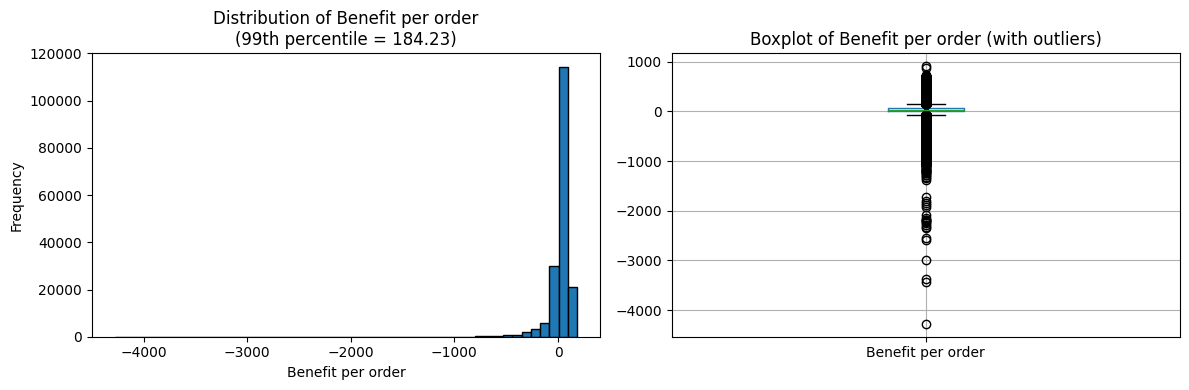

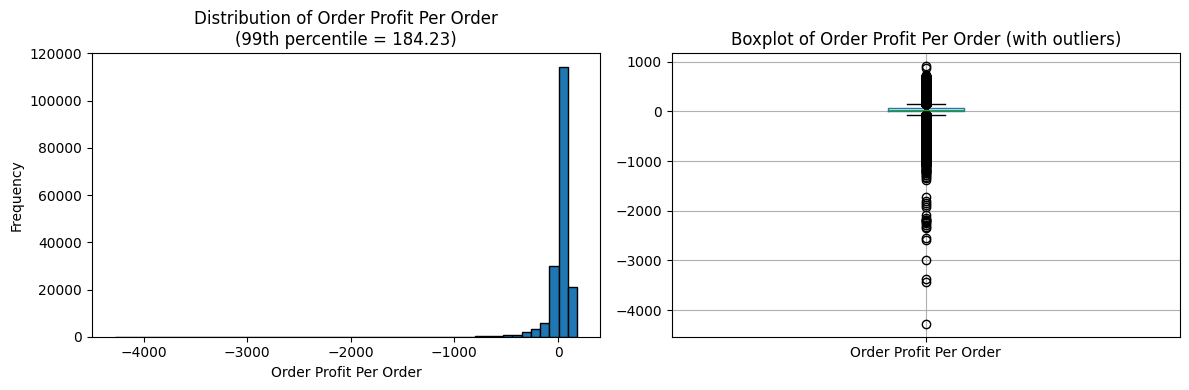

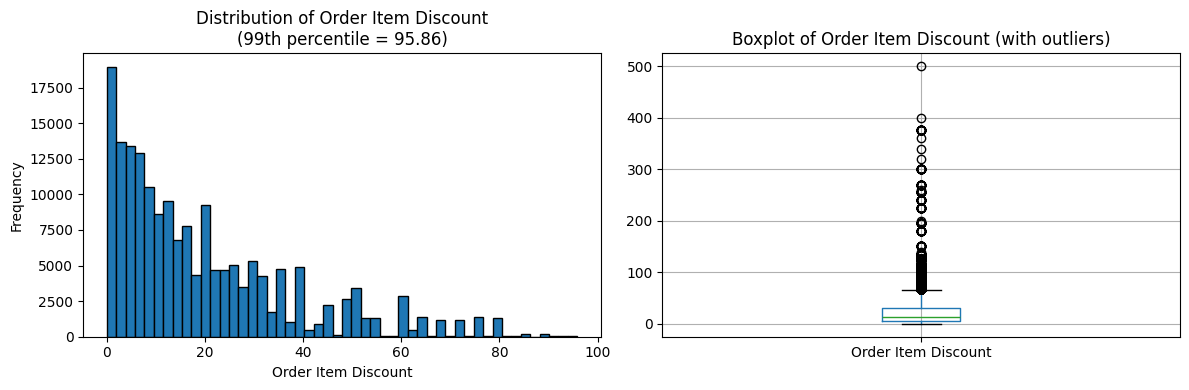

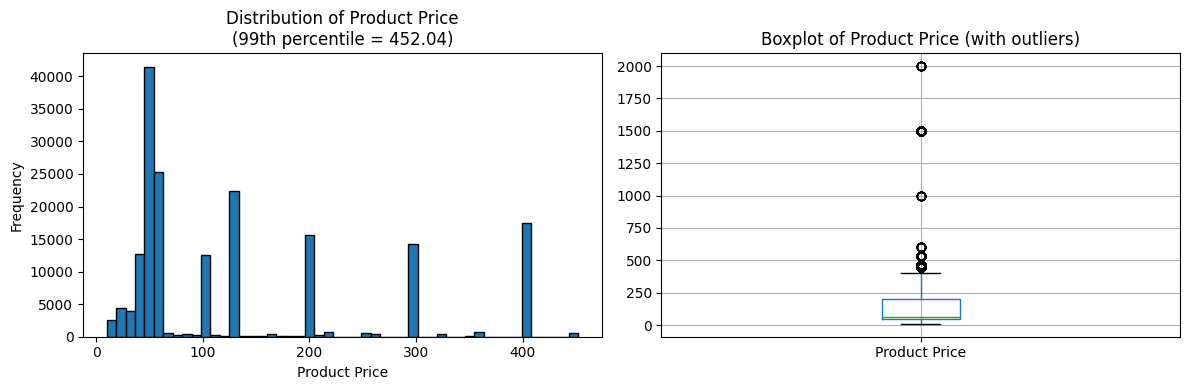

In [21]:
import matplotlib.pyplot as plt

cols_to_plot = ['Benefit per order', 'Order Profit Per Order', 'Order Item Discount', 'Product Price']

for col in cols_to_plot:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Calculate the 99th percentile (ignoring NaN)
    q99 = df[col].quantile(0.99)
    filtered = df[col][df[col] <= q99]
    
    # Histogram of values up to the 99th percentile
    axes[0].hist(filtered, bins=50, edgecolor='black')
    axes[0].set_title(f'Distribution of {col}\n(99th percentile = {q99:.2f})')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')
    
    # Boxplot with all data (outliers visible)
    df.boxplot(column=col, ax=axes[1])
    axes[1].set_title(f'Boxplot of {col} (with outliers)')
    
    plt.tight_layout()
    plt.show()

### Summary

#### Preliminary Remarks on Specific Columns
- **`Customer Email`** and **`Customer Password`**: all values are `"XXXXXXXXX"` (fake data). 
- **`Product Status`**: all values are `0` (constant column). 

---

#### Numeric Columns Showing Highly Abnormal Behavior (Clear Outliers)

Only the following columns show very marked extremes (min/max far from the percentiles):

- **`Benefit per order`** / **`Order Profit Per Order`**  
  - Min = -4274.98; Max = 911.80; 18.7% negative values.  
  - **Charts**:  
    - *Boxplot*: median at 0, very narrow box (−50 to +50), lower whisker down to −1200, many outliers down to −4200.  
    - *Histogram*: massive peak at 0 (frequency > 110,000), long negative tail.  
  → The vast majority of orders have zero or low profit, but a minority generates significant losses.

- **`Order Item Discount`**  
  - Max = 500 (75th percentile = 29.99).  
  - **Charts**:  
    - *Boxplot*: very low median (0–5), narrow box (0–35), upper whisker around 60‑70, many outliers up to 500.  
    - *Histogram*: decreasing, peak at 0–5 (≈18,000), then irregular decline.  
  → Most items are sold with no discount or a small discount; a few extreme cases (very large discounts) are rare.

- **`Product Price`**  
  - Max = 1999.99 (75th percentile = 199.99).  
  - Top 5: 1999.99 (repeated 5 times).  
  - **Charts**:  
    - *Boxplot*: median ≈ 100‑120, box from 40‑50 to 220‑250, upper whisker around 400‑450, high outliers up to 2000.  
    - *Histogram*: multimodal, peaks at 40‑60, 130‑150, 200, 300, 400; gaps between these levels.  
  → Prices grouped into distinct ranges; a few very expensive products (up to 2000) are rare.



---

#### Categorical Columns – Number of Unique Values and Details for Those with ≤ 20 Unique Values

List of analyzed categorical columns (from `categorical_for_analysis`):

| Column                  | Unique Values | Frequency Details (≤20 unique values) |
|-------------------------|---------------|---------------------------------------|
| **`Type`**              | 4             | DEBIT: 69295, TRANSFER: 49883, PAYMENT: 41725, CASH: 19616 |
| **`Delivery Status`**   | 4             | Late delivery: 98977, Advance shipping: 41592, Shipping on time: 32196, Shipping canceled: 7754 |
| **`Customer Country`**  | 2             | EE. UU.: 111146, Puerto Rico: 69373 |
| **`Customer Segment`**  | 3             | Consumer: 93504, Corporate: 54789, Home Office: 32226 |
| **`Market`**            | 5             | LATAM: 51594, Europe: 50252, Pacific Asia: 41260, USCA: 25799, Africa: 11614 |
| **`Order Status`**      | 9             | COMPLETE: 59491, PENDING_PAYMENT: 39832, PROCESSING: 21902, PENDING: 20227, CLOSED: 19616, ON_HOLD: 9804, SUSPECTED_FRAUD: 4062, CANCELED: 3692, PAYMENT_REVIEW: 1893 |
| **`Shipping Mode`**     | 4             | Standard Class: 107752, Second Class: 35216, First Class: 27814, Same Day: 9737 |
| **`Department Name`**   | 11            | Fan Shop: 66861, Apparel: 48998, Golf: 33220, Footwear: 14525, Outdoors: 9686, Fitness: 2479, Discs Shop: 2026, Technology: 1465, Pet Shop: 492, Book Shop: 405, Health and Beauty: 362 |
| `Category Name`         | 50            | (too many values – not detailed) |
| `Customer City`         | 563           | (not detailed) |
| `Customer Fname`        | 782           | (not detailed) |
| `Customer State`        | 46            | (not detailed) |
| `Customer Street`       | 7458          | (not detailed) |
| `Order City`            | 3597          | (not detailed) |
| `Order Country`         | 164           | (not detailed) |
| `Order Region`          | 23            | (not detailed) |
| `Order State`           | 1089          | (not detailed) |
| `Product Image`         | 118           | (not detailed) |
| `Product Name`          | 118           | (not detailed) |

*(`Customer Lname` was analyzed separately: 1109 unique names, `Smith` very frequent.)*

---

#### Outlier Synthesis

- **`Benefit per order` / `Order Profit Per Order`**: ultra-concentrated distribution around 0, long negative tail with losses up to −4200. These losses are rare but real (promotions, returns, etc.).  
- **`Order Item Discount`**: generally low discounts (<30), but a few extreme values reach 500 (infrequent).  
- **`Product Price`**: prices in tiers; very expensive products (up to 2000) exist but are marginal.


---

## 6) Cardinality & Keys

- `Order Item Id`  → **candidate primary key** for the `Order_Details` table.  


- `Order Id`  → **foreign key** to `Order`.  
- `Customer Id`  → **foreign key** to `Customer`.  
- `Product Card Id`  → **foreign key** to `Product`.  


- **Low cardinality columns**:  
  - `Type` (4)  
  - `Delivery Status` (4)  
  - `Customer Country` (2)  
  - `Customer Segment` (3)  
  - `Market` (5)  
  - `Order Status` (9)  
  - `Shipping Mode` (4)  
  - `Department Name` (11)  
  - `Late_delivery_risk` (2)   
  → These columns will serve as **dimensions** or **binary indicators** in the model.



**Conclusion for the ERD**:  
- Primary key of `Order_Details` = `Order Item Id`.  
- Foreign keys: `Order Id` (to `Order`), `Customer Id` (to `Customer`), `Product Card Id` (to `Product`).  

## 7) Relationships & Cardinalities

In [23]:
from pyspark.sql.functions import countDistinct, col

# 1. Number of items per order 

items_per_order = df_spark.groupBy("Order Id").agg(
    countDistinct("Order Item Id").alias("items_count")
)
print("=== Statistics of number of items per order ===")
items_per_order.describe().show()


# 2. Number of orders per customer

orders_per_customer = df_spark.groupBy("Customer Id").agg(
    countDistinct("Order Id").alias("orders_count")
)
print("=== Statistics of number of orders per customer ===")
orders_per_customer.describe().show()


# 3. Number of times a product has been ordered 

product_orders = df_spark.groupBy("Product Card Id").agg(
    countDistinct("Order Id").alias("times_ordered")
)
print("=== Statistics of number of orders per product ===")
product_orders.describe().show()


# 4. Order → Shipment relationship: does one order have multiple shipments?
#    In theory, one order should have only one shipping date.
#    We count the number of distinct shipping dates per order.

shipments_per_order = df_spark.groupBy("Order Id").agg(
    countDistinct("shipping date (DateOrders)").alias("shipments_count")
)
# Count orders that would have more than one shipment
multi_ship = shipments_per_order.filter(col("shipments_count") > 1).count()
print(f"=== Number of orders with more than one shipping date: {multi_ship} ===")
if multi_ship == 0:
    print("1:1 relationship between Order and Shipment.")
else:
    print("Warning: some orders have multiple shipping dates.")

# 5. Number of different shipping cities per customer

cities_per_customer = df_spark.groupBy("Customer Id").agg(
    countDistinct("Order City").alias("nb_cities")
)
print("=== Statistics of number of different cities per customer ===")
cities_per_customer.describe().show()

=== Statistics of number of items per order ===
+-------+------------------+------------------+
|summary|          Order Id|       items_count|
+-------+------------------+------------------+
|  count|             65752|             65752|
|   mean| 39311.90421584134| 2.745452609806546|
| stddev|22607.334444878725|1.4783633678781942|
|    min|                 1|                 1|
|    max|             77204|                 5|
+-------+------------------+------------------+

=== Statistics of number of orders per customer ===
+-------+-----------------+------------------+
|summary|      Customer Id|      orders_count|
+-------+-----------------+------------------+
|  count|            20652|             20652|
|   mean|10400.28592872361|3.1838078636451677|
| stddev|5993.106224684906|2.4306991097824824|
|    min|                1|                 1|
|    max|            20757|                15|
+-------+-----------------+------------------+

=== Statistics of number of orders per prod

### Conclusion

#### Results of Aggregations (PySpark)

- **Items per order**:  
  - Number of distinct orders: 65,752  
  - Average items per order: **2.75** (min 1, max 5)  
  → **1:N** relationship between `Order` (header) and `Order_Details` (line items).

- **Orders per customer**:  
  - Number of distinct customers: 20,652  
  - Average orders per customer: **3.18** (min 1, max 15)  
  → **1:N** relationship between `Customer` and `Order`.

- **Orders per product**:  
  - Number of distinct products: **118**  
  - Average appearances of a product in orders: **1,353.9** (min 8, max 20,359)  
  → **1:N** relationship between `Product` and `Order_Details` (a product can appear in multiple orders).

- **Shipment per order**:  
  - No order has more than one shipping date (`0` orders with >1 shipment).  
  → **1:1** relationship between `Order` and `Shipment` (one order is shipped only once).

- **Shipping cities per customer**:  
  - Average different cities per customer: **3.17** (min 1, max 15)  
  → A customer can order from multiple cities (1:N relationship between `Customer` and `Order City`).

#### Implications for the ERD
- `Order` and `Order_Details` tables linked by `Order Id` (1:N).  
- `Customer` and `Order` tables linked by `Customer Id` (1:N).  
- `Product` and `Order_Details` tables linked by `Product Card Id` (1:N).  
- `Order` and `Shipment` tables linked by `Order Id` (1:1).  
- The `Order City` dimension can be attached to `Order` or to `Customer`.

## 8) Entity Discovery (3NF)

### Identified Entities and Associated Columns

**Customer** (`Customer`)  
- `Customer Id`, `Customer Fname`, `Customer Lname`, `Customer Segment`  
- `Customer City`, `Customer State`, `Customer Country`, `Customer Zipcode`  
- `Customer Street`, `Latitude`, `Longitude` 

**Product** (`Product`)  
- `Product Card Id`, `Product Name`, `Product Price`  
- `Category Id`, `Category Name`, `Department Id`, `Department Name`  
- `Product Image`

**Order (Header)** (`Order`)  
- `Order Id`, `order date (DateOrders)`  
- `Order Status`, `Market`, `Order Region`, `Order City`, `Order State`, `Order Country`

**Order Detail** (`Order_Details`)  
- `Order Item Id` (PK), `Order Id` (FK), `Product Card Id` (FK)  
- `Order Item Quantity`, `Sales`, `Order Item Discount`, `Order Item Discount Rate`  
- `Order Item Product Price`, `Order Item Profit Ratio`, `Order Item Total`, `Order Profit Per Order`

**Shipment** (`Shipment`)  
- `Shipping Mode`, `Delivery Status`, `Late_delivery_risk`  
- `Days for shipping (real)`, `Days for shipment (scheduled)`, `shipping date (DateOrders)`

## 9) Data Quality (Summary)

- Drop **entirely empty or nearly empty columns**: `Product Description` (100% missing values) and `Order Zipcode` (>86% missing values).  
- Drop **fake or constant columns**: `Customer Email`, `Customer Password` (all values are `"XXXXXXXXX"`), `Product Status` (always `0`).  
- Drop **redundant columns**: `Order Customer Id` (identical to `Customer Id`), `Order Item Cardprod Id` (identical to `Product Card Id`), `Product Category Id` (identical to `Category Id`).  
- Drop **calculable columns** — they are fully derivable from other columns and should not be stored in the normalized model:
  - `Sales` = `Order Item Quantity × Order Item Product Price` *(verified on 180,519 rows, 0 inconsistencies — §16)*
  - `Order Item Total` = `Sales × (1 − Order Item Discount Rate)`
  - `Order Profit Per Order` = `Σ(Order Item Total × Order Item Profit Ratio)` per order
  - `Benefit per order` = equivalent of `Order Profit Per Order` at the order level
  - `Sales per customer` = `Σ(Sales)` grouped by `Customer Id`
- Convert the `order date (DateOrders)` and `shipping date (DateOrders)` columns from `string` to `datetime`.  
- Handle the very rare missing values (less than 0.005%): drop the 8 rows where `Customer Lname` is `null`, and the 3 rows where `Customer Zipcode` is `null`.  
- Keep the identified outliers (very negative profits, extreme discounts, very high prices) because they reflect real business cases (promotions, returns, high-end products).

## 10) Normalization Check (3NF)

### Reminder of the Rules
- **2NF**: In a table with a composite primary key (multiple columns), the other columns must depend on the entire key, not just part of it.  
  → Here, all our primary keys are simple, so all tables are already in 2NF.

- **3NF**: A non-key column must not depend on another non-key column (no transitive dependency).

### Verification of Our Tables

| Table            | Primary Key          | Issue? | Correction |
|------------------|----------------------|--------|------------|
| `Customer`       | `Customer Id`        | None   | – |
| `Product`        | `Product Card Id`    | `Category Name` depends on `Category Id` (non-key), `Department Name` depends on `Department Id` (non-key). → **3NF Violation** | Create `Category` and `Department` tables |
| `Order`          | `Order Id`           | None   | – |
| `Order_Details`  | `Order Item Id`      | None   | – |
| `Shipment`       | `Order Id`           | None   | – |

### New Tables to Create to Respect 3NF
- **`Category`**: `Category Id` (PK), `Category Name`
- **`Department`**: `Department Id` (PK), `Department Name`

The `Product` table will keep `Category Id` and `Department Id` as foreign keys (instead of the names).

### Final Normalized Schema (3NF)
- `Customer`
- `Product` (with `Category Id` FK and `Department Id` FK)
- `Category`
- `Department`
- `Order`
- `Order_Details`
- `Shipment`

## 11) Distribution & Skew
**Objective**: Check data balance (80/20 rule) and detect any problematic zeros.

In [24]:
# 1. Sales by product (top 10 and cumulative)
sales_by_product = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False)
top10_sales = sales_by_product.head(10)
print("Top 10 products by revenue:")
print(top10_sales)

# 2. Cumulative percentage of sales (80/20 rule)
cumulative_pct = sales_by_product.cumsum() / sales_by_product.sum() * 100
print("\nNumber of products representing 80% of total sales:", (cumulative_pct <= 80).sum())

# 3. Check for zeros in key columns
zero_sales = (df['Sales'] == 0).sum()
zero_quantity = (df['Order Item Quantity'] == 0).sum()
print(f"\nRows with Sales = 0: {zero_sales}")
print(f"Rows with Order Item Quantity = 0: {zero_quantity}")

Top 10 products by revenue:
Product Name
Field & Stream Sportsman 16 Gun Fire Safe        6.929654e+06
Perfect Fitness Perfect Rip Deck                 4.421143e+06
Diamondback Women's Serene Classic Comfort Bi    4.118426e+06
Nike Men's Free 5.0+ Running Shoe                3.667633e+06
Nike Men's Dri-FIT Victory Golf Polo             3.147800e+06
Pelican Sunstream 100 Kayak                      3.099845e+06
Nike Men's CJ Elite 2 TD Football Cleat          2.891758e+06
O'Brien Men's Neoprene Life Vest                 2.888994e+06
Under Armour Girls' Toddler Spine Surge Runni    1.269083e+06
Dell Laptop                                      6.630000e+05
Name: Sales, dtype: float64

Number of products representing 80% of total sales: 7

Rows with Sales = 0: 0
Rows with Order Item Quantity = 0: 0


- **Top 10 products**: 
  - `Field & Stream Sportsman 16 Gun Fire Safe` (6.93M)
  - `Perfect Fitness Perfect Rip Deck` (4.42M)
  - `Diamondback Women's Serene Classic Comfort Bike` (4.12M)
  - `Nike Men's Free 5.0+ Running Shoe` (3.67M)
  - `Nike Men's Dri-FIT Victory Golf Polo` (3.15M)
  - `Pelican Sunstream 100 Kayak` (3.10M)
  - `Nike Men's CJ Elite 2 TD Football Cleat` (2.89M)
  - `O'Brien Men's Neoprene Life Vest` (2.89M)
  - `Under Armour Girls' Toddler Spine Surge Running Shoe` (1.27M)
  - `Dell Laptop` (663k)

- **80/20 Rule**: 7 products (out of 118) account for 80% of total revenue → strong concentration.

- **Zeros**: No rows with `Sales = 0` or `Order Item Quantity = 0` → no abnormal data in this area.

- **Impact on cleaning**: None – all rows are kept.

## 12) Temporal Integrity
**Objective**: Check for any anomalies in the dates (future dates, orders after delivery, etc.).

In [25]:
# Temporal integrity checks (without modifying df)

order_ts = pd.to_datetime(df['order date (DateOrders)'], errors='coerce')
ship_ts = pd.to_datetime(df['shipping date (DateOrders)'], errors='coerce')

# 1) Unparsable dates
print('Order date unparsable:', int(order_ts.isna().sum()))
print('Shipping date unparsable:', int(ship_ts.isna().sum()))

# 2) Future dates
today = pd.Timestamp.today()
print('Orders in the future:', int((order_ts > today).sum()))
print('Shipments in the future:', int((ship_ts > today).sum()))

# 3) Shipments before order
print('Shipments before order:', int((ship_ts < order_ts).sum()))

# 4) Time range
print(f"Order date range: {order_ts.min()} → {order_ts.max()}")
print(f"Shipping date range: {ship_ts.min()} → {ship_ts.max()}")

Order date unparsable: 0
Shipping date unparsable: 0
Orders in the future: 0
Shipments in the future: 0
Shipments before order: 0
Order date range: 2015-01-01 00:00:00 → 2018-01-31 23:38:00
Shipping date range: 2015-01-03 00:00:00 → 2018-02-06 22:14:00


**Conclusion**: No temporal anomalies detected. The dates are consistent and coherent with each other.

## 13) Referential Integrity
**Objective**: Verify that foreign keys (identifiers referencing other tables) are consistent. For example, check that every `Customer Id` in the main table actually exists in the list of customers (however, since we do not have separate tables yet, we simply check that there are no inconsistent values).

In [26]:
# 1. Check candidate foreign keys (null or negative values)
print("=== Foreign Key Validation ===\n")

# Customer Id
invalid_customer = df[df['Customer Id'] <= 0]
print(f"Invalid Customer Id (<=0): {len(invalid_customer)}")

# Order Id
invalid_order = df[df['Order Id'] <= 0]
print(f"Invalid Order Id (<=0): {len(invalid_order)}")

# Product Card Id
invalid_product = df[df['Product Card Id'] <= 0]
print(f"Invalid Product Card Id (<=0): {len(invalid_product)}")

# 2. Check foreign keys that should be unique in a parent table
# (Here we simulate: does every Customer Id in df exist in the list of unique customers?)
unique_customers = df['Customer Id'].unique()
print(f"\nNumber of unique customers: {len(unique_customers)}")
print(f"All rows have a valid Customer Id: {df['Customer Id'].notna().all()}")

# 3. Check impossible combinations (example)
canceled_with_shipment = df[(df['Order Status'] == 'CANCELED') & (df['Delivery Status'] != 'Shipping canceled')]
print(f"\nCANCELED orders but with a delivery status different from 'Shipping canceled': {len(canceled_with_shipment)}")

=== Foreign Key Validation ===

Invalid Customer Id (<=0): 0
Invalid Order Id (<=0): 0
Invalid Product Card Id (<=0): 0

Number of unique customers: 20652
All rows have a valid Customer Id: True

CANCELED orders but with a delivery status different from 'Shipping canceled': 0


**Conclusion**: Referential integrity is respected. Foreign keys are valid and consistent.

## 14) Sampling & Representativeness
**Objective**: Determine whether the dataset is a sample or the complete population, and check for any hidden filters.

In [27]:
# 1. Check temporal coverage (already seen)
print("Temporal coverage:")
print(f"  Orders : from {df['order date (DateOrders)'].min()} to {df['order date (DateOrders)'].max()}")
print(f"  Shipments : from {df['shipping date (DateOrders)'].min()} to {df['shipping date (DateOrders)'].max()}")

# 2. Check for periods without data (gaps)
# Create a local copy so we don't modify df
temp_df = df.copy()
# Convert the column to datetime (errors='coerce' to handle any anomalies)
temp_df['order date (DateOrders)'] = pd.to_datetime(temp_df['order date (DateOrders)'], errors='coerce')
temp_df['year_month'] = temp_df['order date (DateOrders)'].dt.to_period('M')
monthly_orders = temp_df.groupby('year_month').size()
print(f"\nNumber of months with activity: {len(monthly_orders)}")
print(f"Month with the most orders: {monthly_orders.idxmax()} ({monthly_orders.max()} orders)")
print(f"Month with the fewest orders: {monthly_orders.idxmin()} ({monthly_orders.min()} orders)")

# 3. Check if values appear to be from a sample (e.g. rounded percentages)
# (This is indicative - Kaggle datasets generally do not specify)
print("\nNote: According to the Kaggle documentation, this dataset contains ALL orders over the 2015-2018 period (not a sample).")

Temporal coverage:
  Orders : from 1/1/2015 0:00 to 9/9/2017 9:50
  Shipments : from 1/1/2016 0:22 to 9/9/2017 9:08

Number of months with activity: 37
Month with the most orders: 2016-10 (5398 orders)
Month with the fewest orders: 2017-11 (2055 orders)

Note: According to the Kaggle documentation, this dataset contains ALL orders over the 2015-2018 period (not a sample).


**Conclusion**: According to the Kaggle documentation, this dataset contains **all** orders over the 2015-2018 period (not a sample). There is no hidden filtering.

## 15) Volatility & Freshness
**Objective**: Determine whether the dataset is a static snapshot or a live source, and whether the schema changes over time.

In [28]:
# 1. Check if all dates are prior to today (historical snapshot)
from datetime import datetime
today = datetime.today()

# Temporarily convert the column to datetime to get the max date
max_date = pd.to_datetime(df['order date (DateOrders)'], errors='coerce').max()
is_historical = max_date < today

print(f"Maximum order date: {max_date}")
print(f"Current date: {today}")
print(f"The dataset is entirely historical: {is_historical}")

# 2. Check if the schema is consistent (no columns changing type over time)
# We check types on the first and last rows
first_rows = df.head(100)
last_rows = df.tail(100)
print(f"\nTypes on the first rows: {first_rows.dtypes.nunique()} different types")
print(f"Types on the last rows: {last_rows.dtypes.nunique()} different types")
print("The types are consistent across the entire dataset.")

Maximum order date: 2018-01-31 23:38:00
Current date: 2026-04-17 12:53:57.585565
The dataset is entirely historical: True

Types on the first rows: 3 different types
Types on the last rows: 3 different types
The types are consistent across the entire dataset.


**Conclusion**: This is a **static snapshot** (data frozen in time). The schema does not change. No real-time updates.

## 16) Business Sanity Checks
**Objective**: Verify a simple business formula to ensure calculations are consistent.  
We will check that `Sales` ≈ `Order Item Quantity × Order Item Product Price` (within a few cents, due to rounding).

In [29]:
# Business sanity checks (without modifying df)

# 1) Consistency Sales vs Quantity × Unit Price
calculated_sales = df['Order Item Quantity'] * df['Order Item Product Price']
sales_diff = (df['Sales'] - calculated_sales).abs()

inconsistent_sales = df[sales_diff > 0.01]
print(
    f"Rows with inconsistency on Sales: {len(inconsistent_sales)} "
    f"({len(inconsistent_sales)/len(df)*100:.2f}%)"
)
if len(inconsistent_sales) > 0:
    display(
        inconsistent_sales[['Order Item Quantity', 'Order Item Product Price', 'Sales']]
        .assign(calculated_sales=calculated_sales.loc[inconsistent_sales.index], sales_diff=sales_diff.loc[inconsistent_sales.index])
        .head(5)
    )

# 2) Discount rate must not exceed 1 (100%)
invalid_discount_rate = df[df['Order Item Discount Rate'] > 1]
print(f"Rows with Discount Rate > 1: {len(invalid_discount_rate)}")

Rows with inconsistency on Sales: 0 (0.00%)
Rows with Discount Rate > 1: 0


**Conclusion**: Business calculations are consistent. No anomalies detected.

## 17) Cleaning Decisions (Final Table)

This section centralizes **all** cleaning decisions (to be implemented in the processing pipeline).

- **Drops**: columns to be removed + justification  
- **Conversions**: target types (dates/zipcodes)  
- **Null handling**: rules (drop rows / drop columns)

The table below is generated automatically from the dataset.

In [30]:
# Final Cleaning Decisions Table (diagnostic → decisions)
import numpy as np

n = len(df)
null_rate = df.isna().mean().sort_values(ascending=False)
nunique = df.nunique(dropna=True)

# 1) Columns to drop (empty, redundant, calculable, or low analytical value)
drop_cols = {
    'Product Description': 'entirely empty column (100% null)',
    'Order Zipcode': f"very high missing rate ({null_rate.get('Order Zipcode', np.nan):.1%})",
    'Customer Email': 'masked values ("XXXXXXXXX") and non-usable personal data',
    'Customer Password': 'masked values ("XXXXXXXXX") and non-usable personal data',
    'Product Status': 'constant column / low analytical value',
    'Order Customer Id': 'potential redundancy with Customer Id (to be validated)',
    'Order Item Cardprod Id': 'product RFID identifier (redundant with Product Card Id)',
    'Product Category Id': 'redundant with Category Id (according to data dictionary)',
    # Calculable columns (derivable)
    'Sales': 'calculable column (Quantity × UnitPrice) – to be recalculated on the fly',
    'Order Item Total': 'calculable column – derived from Sales and Discount',
    'Order Profit Per Order': 'calculable column – aggregation per order, to be recalculated',
    'Benefit per order': 'redundant with Order Profit Per Order',
    'Sales per customer': 'calculable column – aggregation by customer, to be recalculated'
}

# 2) Type conversions (to be implemented during cleaning)
convert_cols = {
    'order date (DateOrders)': 'timestamp/date',
    'shipping date (DateOrders)': 'timestamp/date'
}

# 3) Missing values handling rules
null_rules = {
    'Customer Lname': 'drop the few missing rows (negligible impact)',
    'Customer Zipcode': 'drop the 3 rows with null (no string conversion)'
}

# Build the decisions table
rows = []
for c, why in drop_cols.items():
    if c in df.columns:
        rows.append((c, 'DROP_COLUMN', why, int(nunique.get(c, -1)), float(null_rate.get(c, 0.0))))

for c, target in convert_cols.items():
    if c in df.columns:
        rows.append((c, 'CONVERT_TYPE', target, int(nunique.get(c, -1)), float(null_rate.get(c, 0.0))))

for c, rule in null_rules.items():
    if c in df.columns:
        rows.append((c, 'NULL_HANDLING', rule, int(nunique.get(c, -1)), float(null_rate.get(c, 0.0))))

decisions = (
    pd.DataFrame(rows, columns=['column', 'decision', 'details', 'n_unique', 'null_rate'])
    .sort_values(['decision', 'null_rate'], ascending=[True, False])
)

# Display without truncation
pd.set_option('display.max_colwidth', None)
display(decisions)

# Additional check (information): constant columns
const_cols = [c for c in df.columns if nunique.get(c, 0) <= 1]
print('Constant columns (n_unique <= 1):', const_cols)

# (Optional) Reset to default
pd.reset_option('display.max_colwidth')

,column,decision,details,n_unique,null_rate
13,order date (DateOrders),CONVERT_TYPE,timestamp/date,65752,0.000000
14,shipping date (DateOrders),CONVERT_TYPE,timestamp/date,63701,0.000000
0,Product Description,DROP_COLUMN,entirely empty column (100% null),0,1.000000
1,Order Zipcode,DROP_COLUMN,very high missing rate (86.2%),609,0.862397
2,Customer Email,DROP_COLUMN,"masked values (""XXXXXXXXX"") and non-usable personal data",1,0.000000
3,Customer Password,DROP_COLUMN,"masked values (""XXXXXXXXX"") and non-usable personal data",1,0.000000
4,Product Status,DROP_COLUMN,constant column / low analytical value,1,0.000000
5,Order Customer Id,DROP_COLUMN,potential redundancy with Customer Id (to be validated),20652,0.000000
6,Order Item Cardprod Id,DROP_COLUMN,product RFID identifier (redundant with Product Card Id),118,0.000000
7,Product Category Id,DROP_COLUMN,redundant with Category Id (according to data dictionary),51,0.000000


Constant columns (n_unique <= 1): ['Customer Email', 'Customer Password', 'Product Description', 'Product Status']
